
# start2impact University | Progetto Advanced Analytics

Ti diamo il benvenuto nel notebook del progetto del Corso Advanced Analytics!

Prima di tutto bisogna importare una serie di librerie core, che saranno quelle principali per rispondere alle domande del progetto:

In [791]:
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt

Per usare il tuo Google Drive con Colab, bisogna montarlo tramite il seguente comando. Dovrebbe chiederti l'accesso tramite il tuo account Google, concediglielo e seleziona tutte le spunte disponibili.

In [792]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Dopodiché puoi partire con l'importazione del dataset **supermarket sales**, il primo che ti servirà: dovresti averlo già uploadato nel tuo Drive, inserisci la location dove lo hai salvato andando a sostituire il placeholder *{PATH_AL_FILE_SUL_TUO_DRIVE}*, così da importarlo nell'ambiente di lavoro:

In [793]:
# codice per importare il dataset supermarket_sales
regression_raw_dataset = pd.read_csv('/content/drive/MyDrive/5 - DATA ANALYST/7. PROGETTO MACHINE LEARNING/supermarket_sales.csv', encoding='windows-1254')

# Esplorazione del dataset

**In questa breve sezione andrai a visualizzare il dataset in forma tabellare**, così da averne una rappresentazione più intuitiva e comprendere meglio con che tipologia di dato hai a che fare. Per semplicità si mostrano solo le prime 100 occorrenze.

In [794]:
# visualizzazione delle prime 100 righe del dataset
regression_raw_dataset.head(100)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,594-34-4444,A,Yangon,Normal,Male,Electronic accessories,97.16,1,4.8580,102.0180,3/8/2019,20:38,Ewallet,97.16,4.761905,4.8580,7.2
96,766-85-7061,B,Mandalay,Normal,Male,Health and beauty,87.87,10,43.9350,922.6350,3/29/2019,10:25,Ewallet,878.70,4.761905,43.9350,5.1
97,871-39-9221,C,Naypyitaw,Normal,Female,Electronic accessories,12.45,6,3.7350,78.4350,2/9/2019,13:11,Cash,74.70,4.761905,3.7350,4.1
98,865-92-6136,A,Yangon,Normal,Male,Food and beverages,52.75,3,7.9125,166.1625,3/23/2019,10:16,Ewallet,158.25,4.761905,7.9125,9.3


Vai quindi a vedere più nel dettaglio quali sono i metadati principali delle colonne del dataset:

In [795]:
# visualizzazione dei metadati delle colonne (tipo, valori nulli)
regression_raw_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

Da questo puoi già vedere che non ci sono valori nulli, per cui non dovrai usare nessuna strategia per fillarli, altri valori invece sono categorici e quindi bisognerà usare una strategia per codificarli; insomma hai già un po' di informazioni di massima sul dato!
Alcune colonne risultano poco utili ai fini dell'analisi per la predizione e quindi vanno semplicemente eliminate, come per esempio l'ID della fattura, la data della vendita, l'orario e un altro paio:

In [796]:
# eliminazione delle colonne non utili ai fini dell'analisi
regression_dataset = regression_raw_dataset.drop(columns=['Invoice ID', 'Tax 5%', 'Total', 'Date', 'Time', 'cogs', 'gross margin percentage'])

Puoi quindi vedere che alcune colonne sono state rimosse e adesso hai solo quelle che effettivamente sono utili ai fini dello sviluppo del modello:

In [797]:
# verifica delle colonne rimaste dopo la pulizia
regression_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Branch         1000 non-null   object 
 1   City           1000 non-null   object 
 2   Customer type  1000 non-null   object 
 3   Gender         1000 non-null   object 
 4   Product line   1000 non-null   object 
 5   Unit price     1000 non-null   float64
 6   Quantity       1000 non-null   int64  
 7   Payment        1000 non-null   object 
 8   gross income   1000 non-null   float64
 9   Rating         1000 non-null   float64
dtypes: float64(3), int64(1), object(6)
memory usage: 78.3+ KB


# Media, mediana, moda e deviazione standard

Si parte con un esercizio molto semplice, in cui ti chiedo di **calcolare usando numpy la media, la mediana e la moda della colonna su cui andrai a fare predizioni (la label), ovvero Rating**. Ai fini del progetto la colonna Rating acquisisce un significato differente rispetto a quello originale del dataset: essa dà una valutazione alla transazione in base alla redditività della stessa e quindi ti dice quanto è stata proficua la stessa per la catena di supermercati.
Questo ti darà una prima idea di sintesi sui rating assegnati ai vari ordini:

In [798]:
# codice per calcolare la media, mediana e moda della label "Rating"
# Media
media=np.mean(regression_dataset["Rating"])

# Mediana
mediana=np.median(regression_dataset["Rating"])

# Moda
moda= regression_dataset['Rating'].mode()[0]

print(f"Il valore della media è {media}")
print(f"Il valore della mediana è {mediana}")
print(f"Il valore della moda è {moda}")


Il valore della media è 6.9727
Il valore della mediana è 7.0
Il valore della moda è 6.0


Come hai visto durante il Corso, la **deviazione** è una importantissima misura di "sparsità" dei dati, ed è una informazione che è molto utile da ottenere sulla label. Ti chiedo quindi di calcolarla, sempre usando Numpy:

In [799]:
# codice per calcolare la deviazione standard della label "Rating"

std = np.std(regression_dataset['Rating'])

print(f"La deviazione Standard è {std}")

La deviazione Standard è 1.7177207893019182


# Come sono distribuiti i valori della label

A questo punto andiamo a vedere come sono graficamente distribuiti i dati:

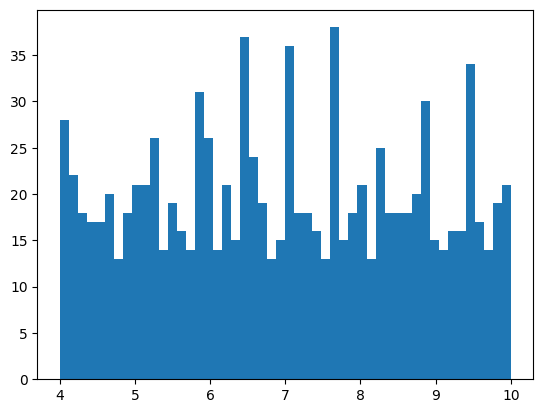

In [800]:
# istogramma della distribuzione del Rating
plt.hist(regression_dataset['Rating'], 50)
plt.show()

Come puoi vedere, la distribuzione dei rating è più o meno uniforme e non c'è skewness.

Il discorso è invece diverso per l'utile lordo:

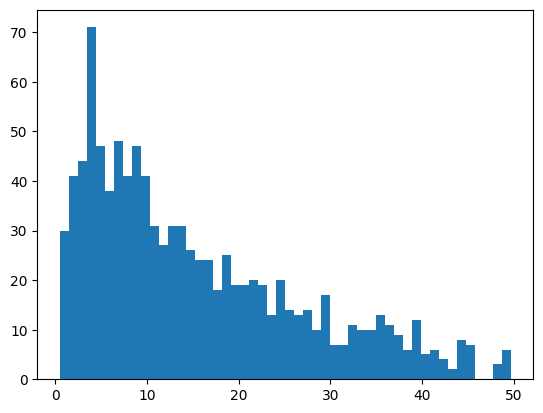

In [801]:
# istogramma della distribuzione del gross income
plt.hist(regression_dataset['gross income'], 50)
plt.show()

Come puoi vedere, qui la skewness c'è eccome e la maggioranza degli ordini sembra avere un income lordo basso.
Qual è, quindi, il valore di questa skewness esattamente? Tocca a te scoprirlo nella prossima cella!

Un piccolo consiglio: farlo con Numpy non è il modo più semplice!

In [802]:
# Codice per calcolare la skewness del gross income
skewness = regression_dataset['gross income'].skew()

print(f'Skewness: {skewness}')

Skewness: 0.8925698049581423


# Encoding delle variabili categoriche

Come avrai sicuramente notato, ci sono delle variabili (come "Branch", "City", "Customer type", "Gender", "Product line" e "Payment") che non sono numeriche e che quindi non possono essere direttamente masticate dagli algoritmi che andrai a utilizzare più tardi.
Ricordi le **tecniche per effettuarne l'enconding**? Questo è il momento di usarle per trasformarle in vettori!

In [803]:
# codice per effettuare l'enconding delle variabili categoriche

#Import OneHotEncoder
from sklearn.preprocessing import OneHotEncoder

encoder=OneHotEncoder(sparse_output=False)
encoded=encoder.fit_transform(regression_dataset[["Branch","City","Customer type","Gender","Product line","Payment"]])

dfencoded=pd.DataFrame(encoded, columns=encoder.get_feature_names_out(["Branch","City","Customer type","Gender","Product line","Payment"]))

dfencoded.head()




,Branch_A,Branch_B,Branch_C,City_Mandalay,City_Naypyitaw,City_Yangon,Customer type_Member,Customer type_Normal,Gender_Female,Gender_Male,Product line_Electronic accessories,Product line_Fashion accessories,Product line_Food and beverages,Product line_Health and beauty,Product line_Home and lifestyle,Product line_Sports and travel,Payment_Cash,Payment_Credit card,Payment_Ewallet
0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [804]:
# Andiamo ad elimiare le colonne categoriche all'interno del DF iniziale
regression_dataset = regression_dataset.drop(columns=["Branch","City","Customer type","Gender","Product line","Payment"])




In [805]:
#  Sostiutiamo le colonne categoriche con quelle trasformate in vettori
df = pd.concat([regression_dataset, dfencoded], axis=1)
df.head()

,Unit price,Quantity,gross income,Rating,Branch_A,Branch_B,Branch_C,City_Mandalay,City_Naypyitaw,City_Yangon,...,Gender_Male,Product line_Electronic accessories,Product line_Fashion accessories,Product line_Food and beverages,Product line_Health and beauty,Product line_Home and lifestyle,Product line_Sports and travel,Payment_Cash,Payment_Credit card,Payment_Ewallet
0,74.69,7,26.1415,9.1,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,15.28,5,3.8200,9.6,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,46.33,7,16.2155,7.4,1.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,58.22,8,23.2880,8.4,1.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,86.31,7,30.2085,5.3,1.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


# Feature Scaling

Nel dataset ci sono alcune feature che potrebbero essere standardizzate/normalizzate: quelle più evidenti sono sicuramente il prezzo del singolo oggetto, ovvero "Unit price", e "gross income" che come hai visto ha una grossa skewness. Questo dovrebbe migliorare la performance dei modelli che andrai a costruire a brevissimo, per cui ti chiedo di procedere in tal senso con la **standardizzazione**:

In [806]:
# codice per effettuare la standardizzazione della colonna "Unit price" e "gross income"
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
df[["Unit price","gross income"]]=scaler.fit_transform(df[["Unit price","gross income"]])


# Train e Test Split

Bene, è quindi giunta l'ora di affrontare l'ultima fase prima di allenare un modello di machine learning: l**o split fra training e test set**!
Per un primo approccio ti suggeriamo di usare una ratio 80:20 o 70:30, che il più delle volte funzionano bene.

Ti chiediamo di chiamare le feature di train, le feature di test, la label di train e le label di test rispettivamente con i nomi *X_train*, *X_test*, *y_train* e *y_test*:

In [807]:
# codice per splittare il dataset in training set e test set
#Assegnazione X e y

X=df.drop(columns=["Rating"])
y=df["Rating"]

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(X,
                                                y,
                                                test_size=0.2,
                                                random_state=42)

# Verifica delle righe e colonne per i valori di X e y

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")




X_train: (800, 22)
X_test:  (200, 22)
y_train: (800,)
y_test:  (200,)


# Linear Regression

Ora è giunto il momento di predire i **Rating** usando il modello più semplice che hai visto, ovvero la linear regression!
Ti chiediamo di chiamare il modello *regressor*.

Procedi pure nella cella che segue:

In [808]:
# training del modello con la linear regression
from sklearn.linear_model import LinearRegression
regressor=LinearRegression()
regressor.fit(X_train,y_train)

# Calcolo di Y predetto tramite il modello precedentemente allenato
y_predit=regressor.predict(X_test)



Adesso che il training è avvenuto è il momento di valutare come questo performa. Le metriche che prendiamo in considerazione, che sono le principali per la regressione lineare, sono **il mean squadred error e il mean absolute error**. Ti chiediamo di calcolarle (sempre usando sklearn), avendo cura di chiamarle rispettivamente *MSE* e *MAE*. Punta a renderle il più vicine allo zero possibile, perché il modello è più di qualità quanto più queste sono zero:

In [809]:
# MSE mean square error
from sklearn.metrics import mean_squared_error
MSE=mean_squared_error(y_test,y_predit)

# MAE mean absolute error
from sklearn.metrics import mean_absolute_error
MAE=mean_absolute_error(y_test,y_predit)


print(MSE)

print(MAE)

# Sia MSE che MAE presentano valori molto elevati, di conseguenza possiamo dire che il modello LinearRegression non è il modello ideale per predirre il rating.

3.110187291026072
1.5229214208487525


In [810]:
# Confronto con test set al 30%, come richiesto dal feedback
X_train_30, X_test_30, y_train_30, y_test_30 = train_test_split(X, y, test_size=0.3, random_state=42)

regressor_30 = LinearRegression()
regressor_30.fit(X_train_30, y_train_30)
y_pred_30 = regressor_30.predict(X_test_30)

MSE_30 = mean_squared_error(y_test_30, y_pred_30)
MAE_30 = mean_absolute_error(y_test_30, y_pred_30)

print(MSE_30)
print(MAE_30)

3.021520322777174
1.498540120280262


In [811]:
# Import di KFold (per dividere il dataset in K parti) e cross_validate
# (per eseguire training e valutazione automaticamente su ogni fold)
from sklearn.model_selection import KFold, cross_validate

# Import della Linear Regression
from sklearn.linear_model import LinearRegression

# Definiamo il modello di Linear Regression
model = LinearRegression()

# Creiamo l'oggetto KFold: divide il dataset in 10 parti uguali,

kf = KFold(n_splits=10, shuffle=True, random_state=42)

# Eseguiamo 10 training/test automatici (uno per ogni fold) e
# calcoliamo MSE e MAE su ognuno in una sola chiamata
risultati = cross_validate(model, X, y, cv=kf,
                           scoring=['neg_mean_squared_error', 'neg_mean_absolute_error'])

# Stampiamo la media di MSE e MAE su tutti i 10 fold.
# Il segno negativo inverte i valori restituiti da sklearn (che li usa negativi internamente)
print(f"MSE medio: {-risultati['test_neg_mean_squared_error'].mean()}")
print(f"MAE medio: {-risultati['test_neg_mean_absolute_error'].mean()}")

MSE medio: 3.0068848642640953
MAE medio: 1.486947408194902


# Commento:
La K-Fold Cross Validation con K=10 restituisce un MSE medio di circa 3.00 e un MAE medio di circa 1.49, valori molto simili a quelli ottenuti con i singoli split 80/20 e 70/30 testati in precedenza.

 Questo risultato ci conferma due cose importanti:
 Il modello è STABILE: le metriche non cambiano significativamente al variare della suddivisione dei dati, quindi i risultati precedenti non erano frutto di uno split fortunato.

 Il modello rimane comunque INADEGUATO per predire il Rating: un MAE di 1.49 su una scala da 4 a 10 (range di 6 punti) rappresenta un errore medio di circa il 25% del range totale, indipendentemente da come suddividiamo i dati.

 La Linear Regression non riesce a catturare una relazione
 significativa tra le feature disponibili e il Rating, e questo vale
 in modo consistente su tutti i 10 fold testati.

### **Commento:**
Aumentando il test set dal 20% al 30%, le metriche migliorano leggermente
(MSE da 3.11 a 3.02, MAE da 1.52 a 1.50). La differenza è minima, di conseguenza possiamo dire che il modello continua a non essere totalemente adeguato per predire il Rating,indipendentemente dalla proporzione train/test scelta.
Questo conferma che il problema non è la dimensione del test set, ma la scarsa relazione lineare tra le feature disponibili e il Rating stesso.

### **Lasso Regression ed eliminazione del rumore delle features**

In [812]:
# Import della Lasso Regression
from sklearn.linear_model import Lasso

# Definiamo il modello Lasso con alpha=0.5
# alpha=0.5
lasso = Lasso(alpha=0.5)

# Eseguiamo la K-Fold Cross Validation con K=10
risultati_lasso = cross_validate(lasso, X, y, cv=kf,
                                 scoring=['neg_mean_squared_error', 'neg_mean_absolute_error'])

# Stampiamo MSE e MAE medi sui 10 fold
print(f"MSE medio Lasso: {-risultati_lasso['test_neg_mean_squared_error'].mean()}")
print(f"MAE medio Lasso: {-risultati_lasso['test_neg_mean_absolute_error'].mean()}")



MSE medio Lasso: 2.9543080876543213
MAE medio Lasso: 1.4784595555555557


La Lasso Regression con alpha=0.5 migliora le performance rispetto alla Linear Regression:

Linear Regression: MSE = 3.0069 | MAE = 1.4869 --> Prima
Lasso (alpha=0.5): MSE = 2.9543 | MAE = 1.4785 --> Adesso

Il parametro alpha=0.5 va ad elimnare le features non rilevanti (bassa relazione con Y che stiamo cercando), portando il loro coefficiente esattamente a zero ed eliminandole automaticamente dal modello.

Grazie a questa selezione automatica delle feature, la Lasso riesce a costruire un modello più pulito e migliorato rispetto alla Linear Regression standard. Questo perchè andando a prendere in modo indiscriminato tutte le features, queste peggioravano il nostro LinearModel.

Il miglioramento è contenuto (MAE da 1.487 a 1.479) ma consistente, confermando che alcune feature del dataset introducevano solo rumore nel modello senza contribuire alla predizione del Rating.

# **LassoCV Regression ed eliminazione del rumore delle features**




In [813]:
# Ripartiamo dal dfencoded e da X e y
X=df.drop(columns=["Rating"])
y=df["Rating"]

# Importamo LassoCV
from sklearn.linear_model import LassoCV

# Definiamo il modello
lasso=LassoCV(cv=10, random_state=42)

# Alleniamo il modello
lasso.fit(X,y)




LassoCV(cv=10, random_state=42)

In [814]:
# Troviamo il valore di Alpha
print(lasso.alpha_)


0.0320446318935619


In [815]:
# Individuiamo le colonne del df che hanno valore uguale a 0
coef = pd.Series(lasso.coef_, index=X.columns)

print(coef)

Unit price                             0.000000
Quantity                              -0.000000
gross income                          -0.030918
Branch_A                               0.000000
Branch_B                              -0.087570
Branch_C                               0.000000
City_Mandalay                         -0.000000
City_Naypyitaw                         0.000000
City_Yangon                            0.000000
Customer type_Member                  -0.000000
Customer type_Normal                   0.000000
Gender_Female                         -0.000000
Gender_Male                            0.000000
Product line_Electronic accessories   -0.000000
Product line_Fashion accessories       0.000000
Product line_Food and beverages        0.000000
Product line_Health and beauty         0.000000
Product line_Home and lifestyle       -0.000000
Product line_Sports and travel        -0.000000
Payment_Cash                          -0.000000
Payment_Credit card                    0

In [816]:
# Teniamo in considerazione solo le colonne con valore diverso da zero
selected_features = coef[coef != 0].index
X_selected = X[selected_features]

X_selected.head()

,gross income,Branch_B
0,0.919607,0.0
1,-0.987730,0.0
2,0.071446,0.0
3,0.675780,0.0
4,1.267125,0.0


In [817]:
# Rieseguiamo la K-Fold Cross Validation con la Linear Regression
# ma questa volta usando solo le feature selezionate dalla LassoCV

model = LinearRegression()

risultati_lasso_cv = cross_validate(model, X_selected, y, cv=kf,
                                    scoring=['neg_mean_squared_error',
                                             'neg_mean_absolute_error'])

print(f"MSE medio: {-risultati_lasso_cv['test_neg_mean_squared_error'].mean()}")
print(f"MAE medio: {-risultati_lasso_cv['test_neg_mean_absolute_error'].mean()}")

MSE medio: 2.95093266024195
MAE medio: 1.4753850721750887


# **Commento**

Utilizzando LassoCV invece di impostare alpha manualmente, il modello ha trovato automaticamente il valore ottimale di alpha tramite Cross Validation a 10 fold:
Alpha ottimale trovato da LassoCV: 0.032
Questo valore è più basso rispetto all'alpha=0.5 precedente, il che significa che la LassoCV ha applicato una "freno" più leggero, mantenendo più feature nel modello ed eliminando solo quelle veramente irrilevanti.

La LassoCV rappresenta quindi la soluzione migliore tra quelle testate: lasciando che sia il modello stesso a trovare il valore ottimale di alpha tramite Cross Validation, si ottiene una selezione delle feature più precisa rispetto alla scelta manuale di alpha=0.5

# **LassoCV Regression, Standar scaler e Polynomial regression**

In [818]:
# Prendiamo il df andanto ad escludere la colonna Rating
X=df.drop(columns=["Rating"])
y=df["Rating"]

In [819]:
# Applicazione di Standard Scaler
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X),
    columns=X.columns,
    index=X.index)



In [820]:
# Step 3: LassoCV per selezionare le feature rilevanti
from sklearn.linear_model import LassoCV
lasso_cv=LassoCV(cv=10, random_state=42)
lasso_cv.fit(X_scaled,y)

LassoCV(cv=10, random_state=42)

In [821]:
# Teniamo solo le feature con coefficiente diverso da zero
coef = pd.Series(lasso_cv.coef_, index=X.columns)
selected_features = coef[coef != 0].index

In [822]:
#  Teniamo solo le feature selezionate
X_selected = X_scaled[selected_features]

In [823]:
# PolynomialFeatures sulle feature selezionate
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_selected)

In [824]:
# K-Fold Cross Validation con Linear Regression

# LinearRegression e addestramento
from sklearn.linear_model import LinearRegression
model=LinearRegression()

# Cross Validation con Linear Regression
from sklearn.model_selection import cross_validate
risultati = cross_validate(model, X_poly, y, cv=10,
                           scoring=['neg_mean_squared_error',
                                    'neg_mean_absolute_error'])



In [825]:
print(f"MSE medio: {-risultati['test_neg_mean_squared_error'].mean()}")
print(f"MAE medio: {-risultati['test_neg_mean_absolute_error'].mean()}")


MSE medio: 2.948628427010093
MAE medio: 1.474866844891722


# **Commento:**
La combinazione StandardScaler, LassoCV, PolynomialFeatures, K-Fold rappresenta il modello migliore testato nel progetto in quanto MAE e MSE hanno i valori più bassi trovati.


Andando a svolgere l'analisi in 4 fasi: 1 ScandardScaler per uniformare i pesi delle serires,

2 LassoCV per individuare le features che pesano maggiormente sul "Rating",

3 applicazione della Polynomial regression per catturare le relazioni non lineari

4 la Cross Validation per valutare il modello, siamo riusciti a trovare MAE di 1.4749 e MSE di 2.948.

Di conseguenza possiamo dire che con un rating min di 4 e max di 10, il modello sbaglia del 25% sul range totale. E i valori trovati dal modello possono avere un errore di più o meno 1.47


# Polynomial Regression

Prova in questa sezione a lavorare in modo simile a quanto fatto per la linear regression, ma usando la polynomial regression, che è sicuramente più potente della prima.

Come prima, ti chiediamo di chiamare *regressor* il modello e *poly_regressor* l'oggetto relativo alle feature polinomiali:

In [826]:
# training del modello con la polynomial regression

# Creazione delle feature polinomiali
from sklearn.preprocessing import PolynomialFeatures
poly_regressor=PolynomialFeatures(degree=2)
X_train_poly = poly_regressor.fit_transform(X_train)
X_test_poly = poly_regressor.transform(X_test)


# Addestramento del modello
from sklearn.linear_model import LinearRegression
regressor=LinearRegression()
regressor.fit(X_train_poly,y_train)

# Predizione
y_pred_poly=regressor.predict(X_test_poly)

# Valutazione
MSE_poly = mean_squared_error(y_test, y_pred_poly)
MAE_poly = mean_absolute_error(y_test, y_pred_poly)

print(MSE_poly)
print(MAE_poly)



3.45261885764412
1.5692996530611787


Come cambiano le performance? C'è effettivamente un miglioramento nell'MSE e nell'MAE?

In [827]:


print('MSE =', MSE, '\nMAE =', MAE)

print('MSE_poly =', MSE_poly, '\nMAE_poly =', MAE_poly)

MSE = 3.110187291026072 
MAE = 1.5229214208487525
MSE_poly = 3.45261885764412 
MAE_poly = 1.5692996530611787



La Polynomial Regression addirittura performa peggio della Linear Regression. Questo potrebbe essere dovuto perché:

Il Rating è poco correlato con le feature disponibili, quindi aggiungere complessità non aiuta. Il modello lavora un numero enorme di combinazioni tra feature, rischiando overfitting sul train set e performando peggio sul test.

# Logistic Regression

In questa sezione si cambia dataset, in quanto cambia la natura del problema: si passa infatti a un problema di classificazione, in cui andrai a valutare la qualità di alcune mele destinate alla catena di supermercati per decidere quali sono le mele di qualità migliore.

La prima cosa è da fare è** importare il nuovo dataset**, ovvero apple_quality, che questa volta ti chiediamo di fare in autonomia, chiamando il dataset *classification_dataset*:

In [828]:
# codice per importare il dataset apple_quality

classification_dataset = pd.read_csv('/content/drive/MyDrive/5 - DATA ANALYST/7. PROGETTO MACHINE LEARNING/apple_quality.csv', encoding='windows-1254')

Ti suggeriamo quindi  di printare le prime 50 righe...

In [829]:
# codice per print delle prime 50 righe
classification_dataset.head(50)

,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,0,-3.970049,-2.512336,5.346330,-1.012009,1.844900,0.329840,-0.491590,good
1,1,-1.195217,-2.839257,3.664059,1.588232,0.853286,0.867530,-0.722809,good
2,2,-0.292024,-1.351282,-1.738429,-0.342616,2.838636,-0.038033,2.621636,bad
3,3,-0.657196,-2.271627,1.324874,-0.097875,3.637970,-3.413761,0.790723,good
4,4,1.364217,-1.296612,-0.384658,-0.553006,3.030874,-1.303849,0.501984,good
5,5,-3.425400,-1.409082,-1.913511,-0.555775,-3.853071,1.914616,-2.981523,bad
6,6,1.331606,1.635956,0.875974,-1.677798,3.106344,-1.847417,2.414171,good
7,7,-1.995462,-0.428958,1.530644,-0.742972,0.158834,0.974438,-1.470125,good
8,8,-3.867632,-3.734514,0.986429,-1.207655,2.292873,4.080921,-4.871905,bad
9,9,-0.727983,-0.442820,-4.092223,0.597513,0.393714,1.620857,2.185608,bad


... e dei metadati delle colonne:

In [830]:
# codice per visualizzare i principali metadata del dataset apple_quality
classification_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   A_id         4000 non-null   int64  
 1   Size         4000 non-null   float64
 2   Weight       4000 non-null   float64
 3   Sweetness    4000 non-null   float64
 4   Crunchiness  4000 non-null   float64
 5   Juiciness    4000 non-null   float64
 6   Ripeness     4000 non-null   float64
 7   Acidity      4000 non-null   float64
 8   Quality      4000 non-null   object 
dtypes: float64(7), int64(1), object(1)
memory usage: 281.4+ KB


Come puoi vedere, il dataset è già pulito e quasi tutte le colonne sono numeriche. L'unica a non esserlo è proprio la label, che va encodata:

In [831]:
# codice per effettuare l'enconding della label "Quality"
apple_quality_dataset=classification_dataset.drop(columns=["A_id"]) #Andiamo ad eliminare la colonna "A_id" perchè è solo un identificativo e includerla potrebbe peggiorare il calcolo dei modelli

from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()
apple_quality_dataset['Quality'] = label.fit_transform(apple_quality_dataset['Quality'])


apple_quality_dataset.head()

,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,-3.970049,-2.512336,5.346330,-1.012009,1.844900,0.329840,-0.491590,1
1,-1.195217,-2.839257,3.664059,1.588232,0.853286,0.867530,-0.722809,1
2,-0.292024,-1.351282,-1.738429,-0.342616,2.838636,-0.038033,2.621636,0
3,-0.657196,-2.271627,1.324874,-0.097875,3.637970,-3.413761,0.790723,1
4,1.364217,-1.296612,-0.384658,-0.553006,3.030874,-1.303849,0.501984,1


Bisogna poi ri-effettuare la divisione fra porzione di addestramento e porzione di test, usando la nomenclatura vista in precedenza:

In [832]:
# codice per splittare in train/test il dataset apple_quality

X_apple=apple_quality_dataset.drop(columns=["Quality",])
y_apple=apple_quality_dataset["Quality"]

X_train,X_test,y_train,y_test=train_test_split(X_apple,
                                               y_apple,
                                               test_size=0.2,
                                               random_state=42)



Puoi finalmente usare la logistic regression per allenare il modello vero e proprio, che ti chiedo di chiamare *logistic_regressor*:

In [833]:
# codice per trainare il modello usando la logistic regression

from sklearn.linear_model import LogisticRegression
logistic_regressor=LogisticRegression()
logistic_regressor.fit(X_train,y_train)



LogisticRegression()

Una metrica che ti permette subito di valutare la bontà del modello, come saprai, è l'***F1 score***, che dovrebbe essere idealmente superiore a 0.80. Cerca anche di massimizzare la media della precision e del recall, che idealmente dovrebbero anch'essi essere superiori a 0.80:

In [834]:
# valutazione del modello tramite classification report (precision, recall, f1-score)
from sklearn.metrics import classification_report
y_predict_test = logistic_regressor.predict(X_test)

print(classification_report(y_test, y_predict_test))


              precision    recall  f1-score   support

           0       0.75      0.76      0.75       401
           1       0.75      0.75      0.75       399

    accuracy                           0.75       800
   macro avg       0.75      0.75      0.75       800
weighted avg       0.75      0.75      0.75       800



Ora è intessante andare a "disegnare" la **confusion matrix**, che ti mostra quali sono le categorie su cui il modello che hai costruito è "bravo" e su quali no, così da eventualmente avere delle informazioni in più per migliorarlo. Prova a farlo in autonomia usando scikit-learn:

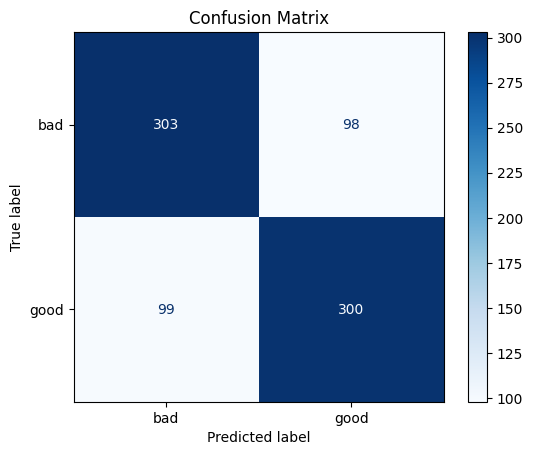

In [835]:
# codice per la confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_predict_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['bad', 'good'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# Decision Tree

**Puoi provare a usare un decision tree per capire se può migliorare le prestazioni del modello basato su logistic regression.** Generalmente, come visto durante la parte teorica del Corso, i decision tree sono più potenti, ma scoprilo costruendone uno!

Il procedimento non è dissimile da quelli usati in precedenza, quindi procedi pure al training:

In [836]:
# training del modello con un decision tree
from sklearn.tree import DecisionTreeClassifier
tree_model=DecisionTreeClassifier()

tree_model.fit(X_train,y_train)
y_treepredict=tree_model.predict(X_test)

In [837]:
# Analisi della bontà del modello con F1 score - I valori sono migliorati rispetto alla Regressione Logistica
from sklearn.metrics import classification_report

prova=classification_report(y_test,y_treepredict)
print(prova)

              precision    recall  f1-score   support

           0       0.81      0.81      0.81       401
           1       0.81      0.81      0.81       399

    accuracy                           0.81       800
   macro avg       0.81      0.81      0.81       800
weighted avg       0.81      0.81      0.81       800



E poi alla costruzione della confusion matrix:

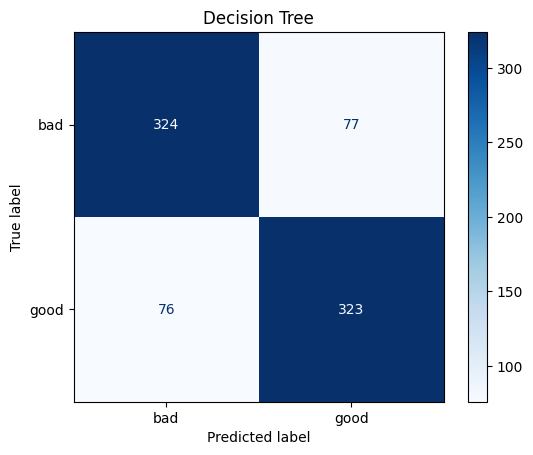

In [838]:
# confusion matrix del decision tree
cm=confusion_matrix(y_test,y_treepredict)
display=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['bad', 'good'])
display.plot(cmap='Blues')
plt.title("Decision Tree")
plt.show()

**Quanti sono gli errori? Di più o di meno di quelli commessi dal modello con la logistic regression?**

Gli errori del modello Decision Tree sono inferiori rispetto alla Regressione Logistica, infatti verificando F1-score del DecisionTree possiamo notare come il valore sia in media dell'80%.

Possiamo affermare che il modello DecisionTree è più flessibile e si adatta meglio in presenza di differenti features, inoltre sarebbe ottimale provare a fare l'analisi anche con il modello Random forest che, visto l'impiego di più Tree, potrebbe andare a fittare ancora meglio le previsioni.

Quali sono le feature che sono state più importanti per il decision tree che hai costruito? Scoprilo con la feature importance, che ti invitiamo a calcolare e poi a printare nella cella che segue:

In [839]:
# codice per la feature importance
feature_importance = pd.Series(tree_model.feature_importances_, index=X_train.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance)


Ripeness       0.206236
Size           0.168859
Sweetness      0.157285
Acidity        0.138270
Juiciness      0.130272
Crunchiness    0.102750
Weight         0.096329
dtype: float64


Dall'analisi feature_importance possiamo notare come "Ripeness" (maturazione) sia il valore che maggiormente incide sulla qualità della mela. Inoltre è importante anche la dolcezza e la taglia mentre il peso non è un indicatore che incide significativamente.

In [840]:
# Tentativo di miglioramento: Random Forest invece di un singolo Decision Tree
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
y_rf_predict = rf_model.predict(X_test)

# Analisi della bontà del modello con F1 score con il Random Forest
print(classification_report(y_test, y_rf_predict))

              precision    recall  f1-score   support

           0       0.91      0.90      0.91       401
           1       0.90      0.91      0.91       399

    accuracy                           0.91       800
   macro avg       0.91      0.91      0.91       800
weighted avg       0.91      0.91      0.91       800



**Commento**

Il Random Forest porta un miglioramento netto: l'F1-score sale dall'81%
al 91%, confermando quanto già intuito nel commento precedente, ovvero
che un approccio basato su più alberi è più robusto e si adatta meglio
alla complessità delle feature delle mele rispetto a un singolo albero
decisionale.

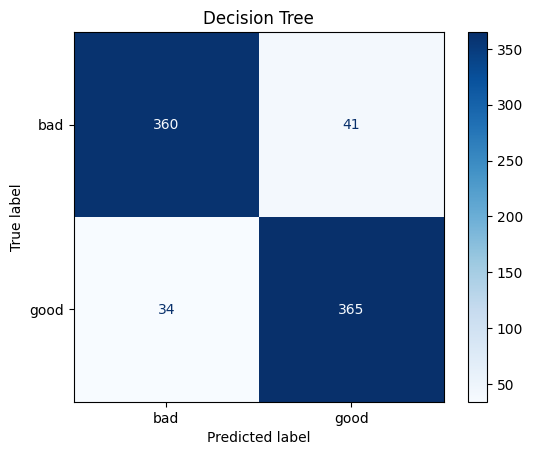

In [841]:
# confusion matrix del Random Forest
cm=confusion_matrix(y_test,y_rf_predict)
display=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['bad', 'good'])
display.plot(cmap='Blues')
plt.title("Decision Tree")
plt.show()

In [ ]:
# Tentativo di miglioramento: Random Forest aggiungendo più criteri

# Miglioramento della configurazione
Rfnew = RandomForestClassifier(
    n_estimators=500,     # più alberi = più robusto
    max_depth=None,        # gli alberi crescono liberamente
    min_samples_leaf=1,    # minimo 1 campione per foglia
    min_samples_split=2,   # minimo 2 campioni per fare uno split
    random_state=42)

# Allenamento nel modello migliorato
Rfnew.fit(X_train,y_train)

# utilizzo del modello per individuare ypredict con gli X_test
y_predictnew=Rfnew.predict(X_test)


In [ ]:
# Analisi della bontà del modello con F1 score con il Random Forest
print(classification_report(y_test, y_predictnew))

In [ ]:
# confusion matrix del Random Forest
cm=confusion_matrix(y_test,y_predictnew)
display=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['bad', 'good'])
display.plot(cmap='Blues')
plt.title("Decision Tree")
plt.show()

## Conclusione:
 Andandando ad aumentare il numero di alberi generati dal modello Random Forest, siamo riusciti ad avere una migliore classificazione.

Con le specifiche aggiunte siamo riusciti ad incrementare di 1 punto percentuale la precisione. Su tutte le mele classificate come "bad", il 92% lo erano davvero. Su tutte le mele classificate come "good", il 91% lo erano davvero. Gli errori di classificazione sono molto pochi.

# K-Means Clustering

Eccoci al K-Means Clustering, il più utilizzato algoritimo tra quelli non supervisionati.

Per prima cosa bisogna eliminare la label perché, come sai, il K-Means Clustering è un algoritmo non supervisionato e non deve quindi averla:

In [ ]:
# Oltre all'eliminazione della label "Quality" sono andato ad eliminare ance la colonna A_id che non è una feature rilevante hai fini dell'applicazione del modello K-Means
clustering_dataset = classification_dataset.drop(columns=['Quality','A_id'])

Prova a trainare il modello usando l'algoritmo in oggetto, il procedimento è sempre simile a quanto visto in precedenza. Prova a settare dapprima il numero dei cluster a due (in quanto sappiamo che il dataset contiene mele buone o non buone):

In [ ]:
# codice per trainare il modello con K-Means Clustering
from sklearn.cluster import KMeans

kmodel=KMeans(n_clusters=3, random_state=42)
kmodel.fit(clustering_dataset)
clustering_dataset["KCluster"]=kmodel.predict(clustering_dataset)




In [ ]:
# confronto tra i cluster trovati dal modello e la label reale di qualità
clustering_dataset["Qualità"]= classification_dataset["Quality"]
clustering_dataset["KCluster"].value_counts()


Effettua quindi una predizione e vedi a che qualità corrisponde la mela che hai dato in input al modello:

In [ ]:
# codice per effettuare la predizione su una mela dalle carattetistiche a piacere
# NUOVA MELA
mela_nuova = pd.DataFrame({
    'Size': [0.5],
    'Weight': [-1.0],
    'Sweetness': [2.5],
    'Crunchiness': [1.2],
    'Juiciness': [1.8],
    'Ripeness': [0.5],
    'Acidity': [-0.5]
})

y_newapple=kmodel.predict(mela_nuova)

if y_newapple ==0:
  print(f"Quality: bad _ {y_newapple}")
elif y_newapple ==1:
  print(f"Quality: medium _ {y_newapple}")
else:
  print(f"Quality: good _ {y_newapple}")

A che cluster è stata assegnata la mela, è buona o cattiva?
Che succede se invece provi a settare il numero di cluster a tre? Testa questo scenario e rifai la predizione, magari potresti scoprire che in realtà ci sono anche delle mele di qualità intermedia!

**Inizialmente impiegando solo 2 clusters la qualità della "mela_nuova" era "bad", tuttavia passando a 3 clusters si è creata una nuova classe di mele con qualità nella media, dove rientra anche la "mela_nuova" aggiunta.**

# Time Series

L'ultimo tema del progetto è quello delle time series: se ci hai fatto caso, il dataset che hai utilizzato per la regressione è in realtà una time series a cui, per il problema di regressione stesso, è stata eliminata l'informazione sul tempo in quanto non utile in quello use case. Adesso è tempo di riprenderla!
In questo scenario vogliamo provare a **capire come i gross income evolvono nel tempo**, quindi prendi il dataset originale, ovvero *regression_raw_dataset* ed elimina tutte le colonne, tenendo solo "Date" e "gross income" e avendo cura di chiamare *timeseries_dataset* il nuovo dataset:

In [ ]:
# codice per costruire un nuovo dataset, partendo da regression_raw_dataset, con solo le colonne "Date" e "gross income"
timeseries_dataset = regression_raw_dataset[["Date", "gross income"]].copy()




Dai un rapido sguardo al nuovo dataset creato, per assicurarti che sia tutto ok:

In [ ]:
# visualizzazione delle prime 100 righe del nuovo dataset timeseries
timeseries_dataset.head(100)

In [ ]:
# verifica del tipo di dato della colonna Date (ancora object)
timeseries_dataset.info()

Il problema della feature "Date" è che al monmento il formato è OBJECT e non possiamo utilizzarlo per allenare la LinearRegression.

Visto che le date del database riguardano i primi 3 mesi del 2019, andiamo a trasformare la colonna data in giorni rispetto a 365 dell'anno.

In [ ]:


#Calcolo dei giorni dal 1 Gennaio per la data
timeseries_dataset["Date"] = pd.to_datetime(timeseries_dataset["Date"], format='%m/%d/%Y')

timeseries_dataset["Date"] = timeseries_dataset["Date"].dt.dayofyear

In [ ]:

# ordinamento cronologico del dataset
timeseries_dataset=timeseries_dataset.sort_values("Date")

In [ ]:

# visualizzazione dell'andamento del gross income nel tempo
plt.plot(timeseries_dataset["Date"], timeseries_dataset["gross income"])
plt.xlabel("Giorno dell'anno")
plt.ylabel("Gross Income")
plt.title("Andamento Gross Income nel tempo")
plt.show()

A questo punto prova a utilizzare la **linear regression** su questa serie temporale, nello stesso modo di quanto già fatto in precedenza:

In [ ]:
# training della time series con la linear regression
X=timeseries_dataset[["Date"]]
y=timeseries_dataset["gross income"]


X_train,X_test,y_train,y_test=train_test_split(X,
                                               y,
                                               test_size=0.2,
                                               random_state=42)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

In [ ]:
# addestramento del modello e predizione sul test set
from sklearn.linear_model import LinearRegression
linearmodel=LinearRegression()
linearmodel.fit(X_train,y_train)

y_predict=linearmodel.predict(X_test)

E vai a controllare le solite metriche, cioè MSE ed MAE:

In [ ]:
# calcolo delle metriche MSE e MAE per il modello time series
MSE=mean_squared_error(y_test,y_predict)

MAE=mean_absolute_error(y_test,y_predict)

print('MSE =', MSE, '\nMAE =', MAE)

In [ ]:
# Per caipre se i valori di MSE e MAE sono significativi e il modello non è attendibile, andiamo ad analizzare qual'è il valore minino e massimo del gross income:

timeseries_dataset["gross income"].describe()

Il gross income varia tra un minimo di 0.51 e un massimo di 49.65, con una media di 15.38.
Un MAE di 9.67 rappresenta quindi circa il 63% della media del gross income,
un errore molto elevato in proporzione. UNn MAE di 9.67 significa che il modello sbaglia in media di ±9.67 unità per ogni preddizione.

Questo conferma che il modello di Linear Regression non riesce a catturare un pattern predittivo affidabile usando solo il giorno dell'anno.

Ti renderai conto che probabilmente non sono così elevati come in precedenza, questo perché la regressione lineare sulle time series spesso fallisce e, come già visto nella teoria, c'è bisogno di altri modelli più perfomanti.

# Time Series con XGBoost (opzionale)

A proposito di modelli più performanti per le time series, ricordi XGBoost? Se ti va, puoi provare a impiegare quest'ultimo per costruire il modello. **Questa sezione è opzionale e non necessaria per superare il progetto.**

In [ ]:
# (BONUS) training e performance evalutation della time series con XGBoost

from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_predict_xgb = xgb_model.predict(X_test)

In [ ]:
# calcolo delle metriche per il modello XGBoost
MSE_xgb = mean_squared_error(y_test, y_predict_xgb)
MAE_xgb = mean_absolute_error(y_test, y_predict_xgb)

In [ ]:
# stampa dei risultati ottenuti con XGBoost
print(f"MSE_xgb = {MSE_xgb:.4f}")
print(f"MAE_xgb = {MAE_xgb:.4f}")

I risultati confermano quanto ipotizzato, una sola serie "Giorno dell'anno" non ha nessuna relazione con i ricavi lordi. Nonostante l'applicazione del modello XGBoost (più performante rispetto alla Linear Regression), in questo esempio performa persino peggio del ML precedente. Possiamo quindi concludere che il problema non è il modello ma le features a disposizioni e non è presente una relazione tra giorno dell'anno e gross income.

**Proviamo adesso a prendere solo la serie gross income e creando una feature target ["Vendite_gg+1"] per capire se è presente una relazione tra le vendite odierne e le vendite del giorno dopo**

In [ ]:
#Dataset iniziale

timeseries_dataset=regression_raw_dataset[["Date","gross income"]]

#Ordinamento del DataFrame per Data

timeseries_dataset["Date"]=pd.to_datetime(timeseries_dataset["Date"], format='%m/%d/%Y')

timeseries_dataset=timeseries_dataset.sort_values("Date")

#Raggruppamento dei ricavi lordi generati ogni giorno dell'anno

timeseries_dataset=timeseries_dataset.groupby("Date")["gross income"].sum().reset_index()

timeseries_dataset.head()



In [ ]:
#Eliminazione della colonna Data
timeseries_dataset=timeseries_dataset.drop(columns=["Date"])

#Creazione della feature target ["Vendite_gg+1"]

timeseries_dataset["Vendite_gg+1"]=timeseries_dataset["gross income"].shift(-1)




In [ ]:
timeseries_dataset.head(100000)

In [ ]:
timeseries_dataset=timeseries_dataset.dropna()

In [ ]:
#Impiego del Train Test

X=timeseries_dataset[["gross income"]]
y=timeseries_dataset["Vendite_gg+1"]

X_train,X_test,y_train,y_test=train_test_split(X,
                                               y,
                                               test_size=0.2,
                                               random_state=42)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")


In [ ]:
#Allenamento del modello

model=LinearRegression()
model.fit(X_train,y_train)


In [ ]:
#Verifica dei risultati ottenuti attraverso utilizzo di MSE e MAE

y_predetto =model.predict(X_test)

MSE=mean_squared_error(y_test,y_predetto)
MAE=mean_absolute_error(y_test,y_predetto)


print(f"MSE: {MSE}")
print(F"MAE: {MAE}")

Anche in questo caso la correlazione è quasi nulla
MAE di 47.59 rappresenta un errore importante nel nostro DF e significa che il modello sbaglia in media di 48 unità per ogni giorno su gross income. In conclusione: il gross income di un giorno non permette di prevedere quello del giorno successivo. La serie si comporta come rumore quasi casuale.

Per costruire un modello predittivo realmente utile servirebbero altre informazioni (giorno della settimana, eventi stagionali, promozioni)